# ３章１節４項 局所閾値手法による洪水域抽出

## 概要
切り抜いたSentinel-1画像を用いて、局所閾値手法により水域を抽出し、災害前後の差分から洪水域を検出します。
四分木分割と変動係数分析を組み合わせることで、局所的に最適な閾値を自動決定し、精度の高い洪水域抽出を実現します。

## 使用データ

| 項目 | 情報 |
| ---- | ---- |
| 衛星 | Sentinel-1A/1B |
| データパス | /work/data/water/clipped/ |
| データ形式 | GeoTIFF (VV偏波、dB値) |
| 災害前撮影日時 | 2019年9月24日 (Sentinel-1A) |
| 災害後撮影日時 | 2019年10月12日 (Sentinel-1B) |
| 対象災害 | 令和元年台風第19号による洪水（福島県郡山市周辺） |
| 画像サイズ | 300 × 300 ピクセル |
| 画像クレジット | Contains modified Copernicus Sentinel data |

In [58]:
# 必要なライブラリのインポート
import os
import warnings

import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import japanize_matplotlib

# 警告メッセージを非表示
warnings.filterwarnings('ignore')

In [59]:
# 入力データと出力先のパス設定
PATH_INPUT = '/work/data/water/'
PATH_OUTPUT = '/work/outputs/water/'

# 入力ファイル名
INPUT_BEFORE = 'S1A_20190924_clipped.tif'  # 災害前
INPUT_AFTER = 'S1B_20191012_clipped.tif'   # 災害後

# マルチルック処理パラメータ
MULTILOOK_SIZE = 2          # マルチルック処理のウィンドウサイズ（2×2）

# 四分木分割パラメータ
TILE_SIZE = 8               # L+タイルのサイズ（8×8ピクセル）

# 変動係数の閾値パラメータ
CV_PERCENTILE_BEFORE = 90   # 災害前の変動係数パーセンタイル（90%）
CV_PERCENTILE_AFTER = 80    # 災害後の変動係数パーセンタイル（80%）

# 2回目の閾値処理パラメータ（災害前の水域精緻化用）
RETILE_SIZE = 4             # 再タイル化のサイズ（4×4ピクセル）
RECV_PERCENTILE = 80        # 再処理の変動係数パーセンタイル（80%）

# 出力ディレクトリが存在しない場合は作成
os.makedirs(PATH_OUTPUT, exist_ok=True)

# 切り抜き画像の読み込みと確認

In [60]:
# 災害前画像の読み込み
IMG_PATH_BEFORE = os.path.join(PATH_INPUT, INPUT_BEFORE)
with rio.open(IMG_PATH_BEFORE) as src:
    img_before = src.read(1).astype(np.float32)
    meta_before = src.meta.copy()

# 災害後画像の読み込み
IMG_PATH_AFTER = os.path.join(PATH_INPUT, INPUT_AFTER)
with rio.open(IMG_PATH_AFTER) as src:
    img_after = src.read(1).astype(np.float32)
    meta_after = src.meta.copy()

print('=' * 60)
print('切り抜き画像情報')
print('=' * 60)
print(f'災害前画像サイズ: {img_before.shape[0]} × {img_before.shape[1]} ピクセル')
print(f'災害後画像サイズ: {img_after.shape[0]} × {img_after.shape[1]} ピクセル')
print(f'データ型: {img_before.dtype}')
print(f'災害前dB値の範囲: {np.nanmin(img_before):.2f} - {np.nanmax(img_before):.2f}')
print(f'災害後dB値の範囲: {np.nanmin(img_after):.2f} - {np.nanmax(img_after):.2f}')
print('=' * 60)

切り抜き画像情報
災害前画像サイズ: 300 × 300 ピクセル
災害後画像サイズ: 300 × 300 ピクセル
データ型: float32
災害前dB値の範囲: -23.27 - 22.94
災害後dB値の範囲: -23.90 - 30.80


# マルチルック処理

In [61]:
def apply_multilook(image, multilook_size):
    """
    マルチルック処理を実施する関数
    
    スペックルノイズを低減するため、指定されたサイズのウィンドウで平均化します。
    
    Parameters:
    -----------
    image : ndarray
        入力画像（2次元配列）
    multilook_size : int
        マルチルックウィンドウサイズ（multilook_size × multilook_size）
    
    Returns:
    --------
    multilooked_data : ndarray
        マルチルック処理後の画像
    """
    # 画像をmultilook_sizeで割り切れるサイズに調整
    height, width = image.shape
    new_height = height - (height % multilook_size)
    new_width = width - (width % multilook_size)
    
    image_clipped = image[:new_height, :new_width]
    
    # multilook_size × multilook_size のブロックに分割して平均化
    reshaped_data = image_clipped.reshape(
        (image_clipped.shape[0] // multilook_size, multilook_size,
         image_clipped.shape[1] // multilook_size, multilook_size)
    )
    
    multilooked_data = reshaped_data.mean(axis=(1, 3))
    
    return multilooked_data


# マルチルック処理の実行
before_multilooked = apply_multilook(img_before, MULTILOOK_SIZE)
after_multilooked = apply_multilook(img_after, MULTILOOK_SIZE)

print('=' * 60)
print('マルチルック処理完了')
print('=' * 60)
print(f'災害前 - 処理前サイズ: {img_before.shape[0]} × {img_before.shape[1]} ピクセル')
print(f'災害前 - 処理後サイズ: {before_multilooked.shape[0]} × {before_multilooked.shape[1]} ピクセル')
print(f'災害後 - 処理前サイズ: {img_after.shape[0]} × {img_after.shape[1]} ピクセル')
print(f'災害後 - 処理後サイズ: {after_multilooked.shape[0]} × {after_multilooked.shape[1]} ピクセル')
print(f'マルチルックサイズ: {MULTILOOK_SIZE}×{MULTILOOK_SIZE}')
print('=' * 60)

マルチルック処理完了
災害前 - 処理前サイズ: 300 × 300 ピクセル
災害前 - 処理後サイズ: 150 × 150 ピクセル
災害後 - 処理前サイズ: 300 × 300 ピクセル
災害後 - 処理後サイズ: 150 × 150 ピクセル
マルチルックサイズ: 2×2


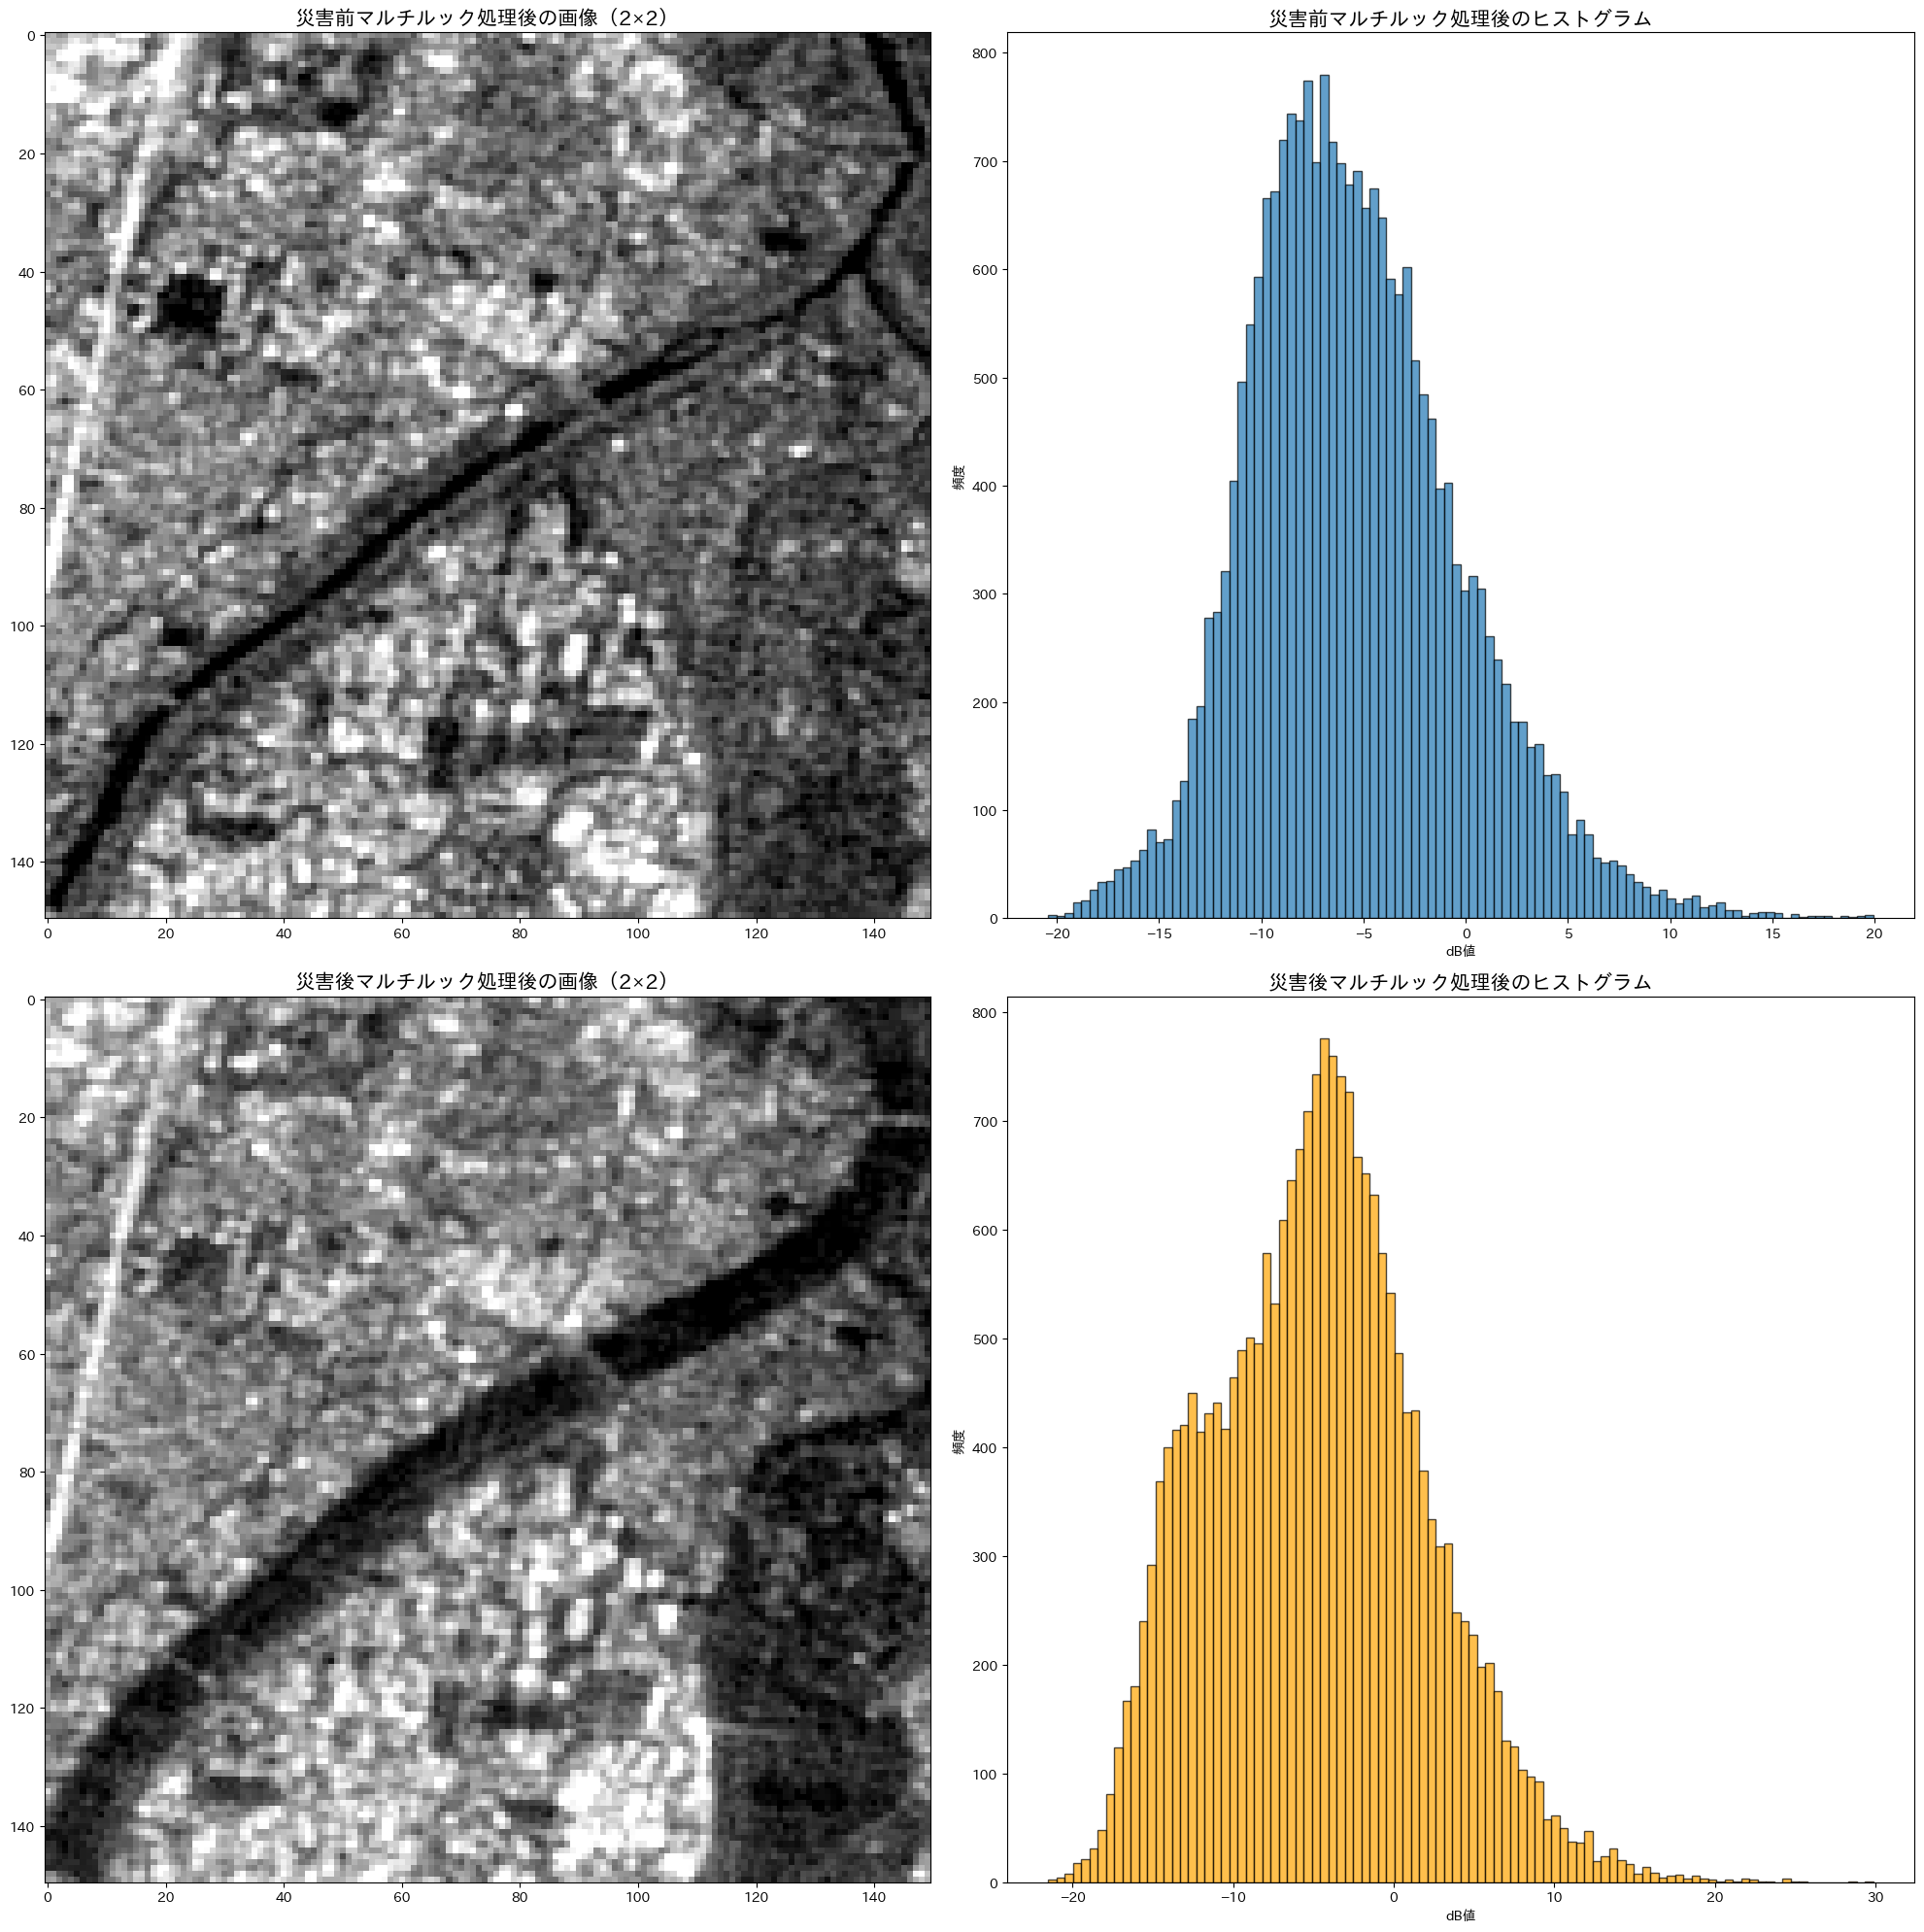

In [62]:
# マルチルック処理後の画像とヒストグラムを可視化
p2_before, p98_before = np.nanpercentile(before_multilooked, [2, 98])
p2_after, p98_after = np.nanpercentile(after_multilooked, [2, 98])

fig, axes = plt.subplots(2, 2, figsize=(20, 20))

# 災害前
axes[0, 0].imshow(before_multilooked, cmap='gray', vmin=p2_before, vmax=p98_before)
axes[0, 0].set_title(f'災害前マルチルック処理後の画像（{MULTILOOK_SIZE}×{MULTILOOK_SIZE}）', fontsize=15)
axes[0, 0].set_aspect('equal')

axes[0, 1].hist(before_multilooked[~np.isnan(before_multilooked)].flatten(), bins=100, edgecolor='black', alpha=0.7)
axes[0, 1].set_title('災害前マルチルック処理後のヒストグラム', fontsize=15)
axes[0, 1].set_xlabel('dB値')
axes[0, 1].set_ylabel('頻度')
axes[0, 1].set_aspect('auto')

# 災害後
axes[1, 0].imshow(after_multilooked, cmap='gray', vmin=p2_after, vmax=p98_after)
axes[1, 0].set_title(f'災害後マルチルック処理後の画像（{MULTILOOK_SIZE}×{MULTILOOK_SIZE}）', fontsize=15)
axes[1, 0].set_aspect('equal')

axes[1, 1].hist(after_multilooked[~np.isnan(after_multilooked)].flatten(), bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_title('災害後マルチルック処理後のヒストグラム', fontsize=15)
axes[1, 1].set_xlabel('dB値')
axes[1, 1].set_ylabel('頻度')
axes[1, 1].set_aspect('auto')

plt.savefig(os.path.join(PATH_OUTPUT, 'figure46.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

# 四分木分割による領域タイル化

In [63]:
def create_tiles(image, tile_size):
    """
    2段階の四分木分割を実施してタイルを生成する関数
    
    画像を指定されたサイズのタイル（L+）に分割し、さらに各L+タイルを
    4つのサブタイル（L-）に分割します。欠損値を含むタイルは除外されます。
    
    Parameters:
    -----------
    image : ndarray
        入力画像（2次元配列）
    tile_size : int
        L+タイルのサイズ（tile_size × tile_size ピクセル）
    
    Returns:
    --------
    l_plus : list of ndarray
        L+タイルのリスト
    l_plus_positions : list of tuple
        L+タイルの位置情報（y_start, y_end, x_start, x_end）
    l_minus : list of list of ndarray
        L-タイルのリスト（各L+タイルに対応する4つのL-タイル）
    l_minus_positions : list of list of tuple
        L-タイルの位置情報
    """
    # 画像サイズをタイルサイズの倍数に調整
    height, width = image.shape
    new_height = (height // tile_size) * tile_size
    new_width = (width // tile_size) * tile_size
    image = image[:new_height, :new_width]
    
    # タイル数を計算
    n_rows = new_height // tile_size
    n_cols = new_width // tile_size
    
    # L+とL-のタイルを生成
    l_plus = []
    l_plus_positions = []
    l_minus = []
    l_minus_positions = []
    
    for i in range(n_rows):
        for j in range(n_cols):
            y_start = i * tile_size
            y_end = (i + 1) * tile_size
            x_start = j * tile_size
            x_end = (j + 1) * tile_size
            l_plus_tile = image[y_start:y_end, x_start:x_end]
            
            # 欠損値がないL+タイルのみを処理
            if not np.isnan(l_plus_tile).any():
                l_plus.append(l_plus_tile)
                l_plus_positions.append((y_start, y_end, x_start, x_end))
                
                # L-タイルの生成（L+を4分割）
                l_minus_tiles = []
                l_minus_tiles_positions = []
                half_tile_size = tile_size // 2
                
                for y in range(0, tile_size, half_tile_size):
                    for x in range(0, tile_size, half_tile_size):
                        l_minus_tile = l_plus_tile[y:y+half_tile_size, x:x+half_tile_size]
                        l_minus_tiles.append(l_minus_tile)
                        l_minus_tiles_positions.append(
                            (y_start + y, y_start + y + half_tile_size,
                             x_start + x, x_start + x + half_tile_size)
                        )
                
                l_minus.append(l_minus_tiles)
                l_minus_positions.append(l_minus_tiles_positions)
    
    return l_plus, l_plus_positions, l_minus, l_minus_positions


def tile_visualization(image, l_plus_positions, l_minus_positions, title, output_filename):
    """
    四分木分割の結果を可視化する関数
    
    L+タイルを赤枠、L-タイルを青枠で画像上に表示します。
    
    Parameters:
    -----------
    image : ndarray
        ベース画像
    l_plus_positions : list of tuple
        L+タイルの位置情報
    l_minus_positions : list of list of tuple
        L-タイルの位置情報
    title : str
        図のタイトル
    output_filename : str
        出力ファイル名
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    p2, p98 = np.nanpercentile(image, [2, 98])
    ax.imshow(image, cmap='gray', vmin=p2, vmax=p98)
    
    # L+のタイル群を可視化（赤枠）
    for i in range(len(l_plus_positions)):
        y_start, y_end, x_start, x_end = l_plus_positions[i]
        rect = plt.Rectangle(
            (x_start, y_start), x_end-x_start, y_end-y_start,
            edgecolor='red', facecolor='none', linewidth=1
        )
        ax.add_patch(rect)
    
    # L-のタイル群を可視化（青枠）
    for i in range(len(l_minus_positions)):
        for j in range(len(l_minus_positions[i])):
            y_start, y_end, x_start, x_end = l_minus_positions[i][j]
            rect = plt.Rectangle(
                (x_start+0.5, y_start+0.5), x_end-x_start-1, y_end-y_start-1,
                edgecolor='blue', facecolor='none', linewidth=1
            )
            ax.add_patch(rect)
    
    ax.set_title(title, fontsize=14)
    plt.savefig(os.path.join(PATH_OUTPUT, output_filename), dpi=150, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

四分木分割完了
災害前 - L+タイル数: 324
災害後 - L+タイル数: 324
L+タイルサイズ: 8×8 ピクセル
L-タイルサイズ: 4×4 ピクセル


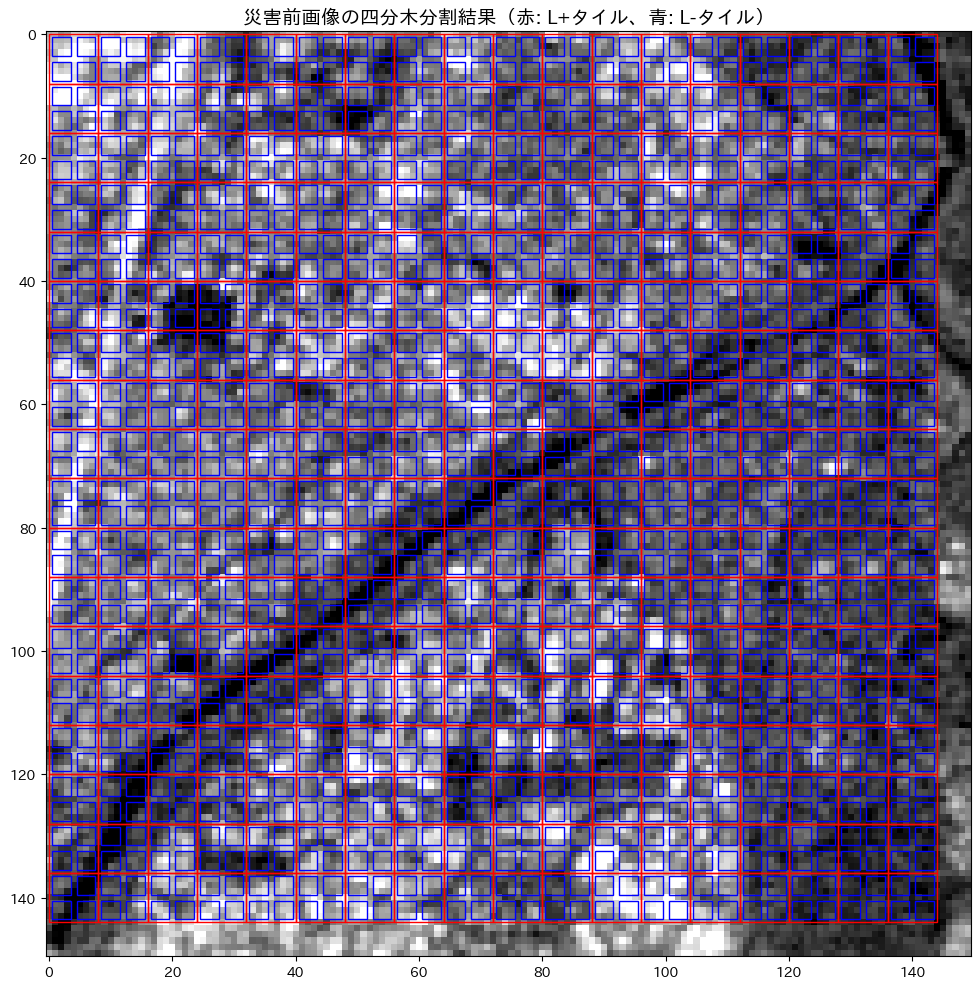

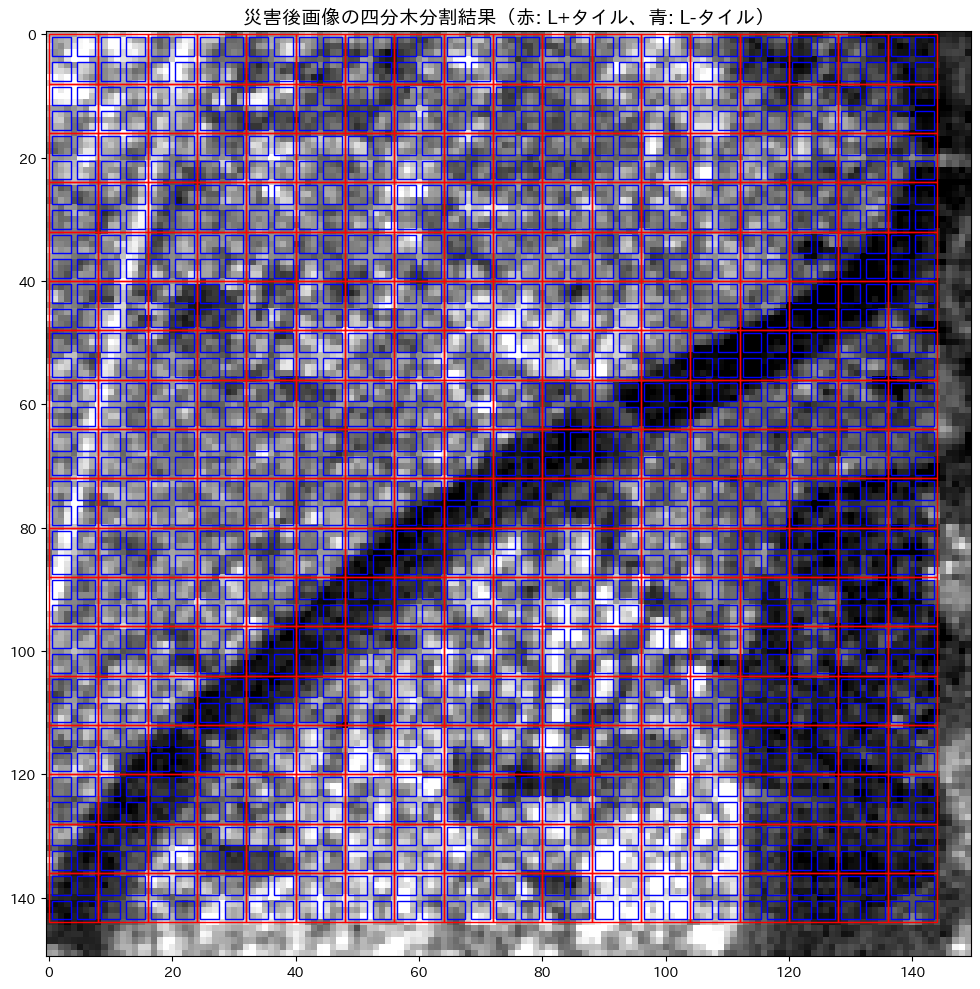

In [64]:
# 災害前画像の四分木分割
before_l_plus, before_l_plus_positions, before_l_minus, before_l_minus_positions = create_tiles(
    before_multilooked,
    tile_size=TILE_SIZE
)

# 災害後画像の四分木分割
after_l_plus, after_l_plus_positions, after_l_minus, after_l_minus_positions = create_tiles(
    after_multilooked,
    tile_size=TILE_SIZE
)

print('=' * 60)
print('四分木分割完了')
print('=' * 60)
print(f'災害前 - L+タイル数: {len(before_l_plus)}')
print(f'災害後 - L+タイル数: {len(after_l_plus)}')
print(f'L+タイルサイズ: {TILE_SIZE}×{TILE_SIZE} ピクセル')
print(f'L-タイルサイズ: {TILE_SIZE//2}×{TILE_SIZE//2} ピクセル')
print('=' * 60)

# 四分木分割の可視化
tile_visualization(
    before_multilooked,
    before_l_plus_positions,
    before_l_minus_positions,
    '災害前画像の四分木分割結果（赤: L+タイル、青: L-タイル）',
    'figure47.png'
)

tile_visualization(
    after_multilooked,
    after_l_plus_positions,
    after_l_minus_positions,
    '災害後画像の四分木分割結果（赤: L+タイル、青: L-タイル）',
    'figure48.png'
)

# 変動係数による水域候補領域の抽出

In [65]:
def calculate_coefficient_of_variation(l_plus, l_minus):
    """
    L+タイルとL-タイルの統計情報から変動係数を算出する関数
    
    各L+タイル内のL-タイルの平均値の標準偏差を、L+タイルの平均値で正規化することで
    変動係数を計算します。変動係数が大きいタイルは、水域と非水域の境界を含む可能性が高いです。
    
    Parameters:
    -----------
    l_plus : list of ndarray
        L+タイルのリスト
    l_minus : list of list of ndarray
        L-タイルのリスト
    
    Returns:
    --------
    coefficients_of_variation : list of float
        各L+タイルの変動係数
    """
    coefficients_of_variation = []
    
    for i, l_plus_tile in enumerate(l_plus):
        l_minus_tiles = l_minus[i]
        l_minus_means = [np.mean(tile) for tile in l_minus_tiles]
        mean_std = np.std(l_minus_means)
        l_plus_mean = np.mean(l_plus_tile)
        coefficient_of_variation = mean_std / l_plus_mean
        coefficients_of_variation.append(coefficient_of_variation)
    
    return coefficients_of_variation


def extract_top_percentile(coefficients_of_variation, percentile):
    """
    変動係数のリストから指定したパーセンタイルを超えるインデックスと値を抽出する関数
    
    Parameters:
    -----------
    coefficients_of_variation : list of float
        変動係数のリスト
    percentile : float
        抽出する閾値のパーセンタイル（0-100）
    
    Returns:
    --------
    top_coefficients : list of tuple
        (インデックス, 変動係数) のタプルのリスト
    """
    threshold = np.percentile(coefficients_of_variation, percentile)
    
    top_coefficients = []
    for i, cv in enumerate(coefficients_of_variation):
        if cv > threshold:
            top_coefficients.append((i, cv))
    
    return top_coefficients


def visualize_top_tiles(image, l_plus_positions, top_coefficients, title, output_filename):
    """
    変動係数を基に抽出したタイルを可視化する関数
    
    Parameters:
    -----------
    image : ndarray
        ベース画像
    l_plus_positions : list of tuple
        L+タイルの位置情報
    top_coefficients : list of tuple
        上位変動係数のタイル情報
    title : str
        図のタイトル
    output_filename : str
        出力ファイル名
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    p2, p98 = np.nanpercentile(image, [2, 98])
    ax.imshow(image, cmap='gray', vmin=p2, vmax=p98)
    
    for i, cv in top_coefficients:
        y_start, y_end, x_start, x_end = l_plus_positions[i]
        rect = plt.Rectangle(
            (x_start, y_start), x_end - x_start, y_end - y_start,
            edgecolor='red', facecolor='none', linewidth=2
        )
        ax.add_patch(rect)
    
    ax.set_title(title, fontsize=14)
    plt.savefig(os.path.join(PATH_OUTPUT, output_filename), dpi=150, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

変動係数分析結果
災害前 - 変動係数の範囲: -11.2647 - 12.5381
災害前 - 90パーセンタイル閾値: -0.0620
災害前 - 抽出されたタイル数: 33
------------------------------------------------------------
災害後 - 変動係数の範囲: -147.0207 - 116.0529
災害後 - 80パーセンタイル閾値: -0.0631
災害後 - 抽出されたタイル数: 65


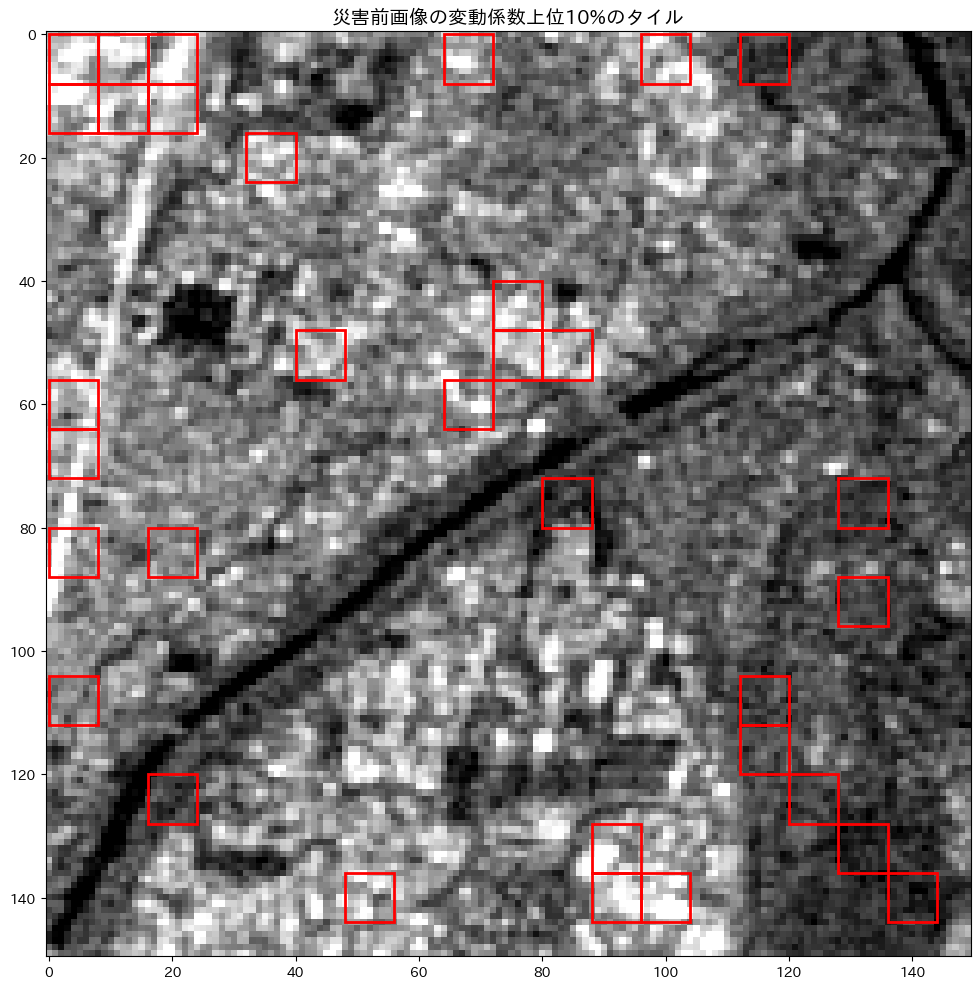

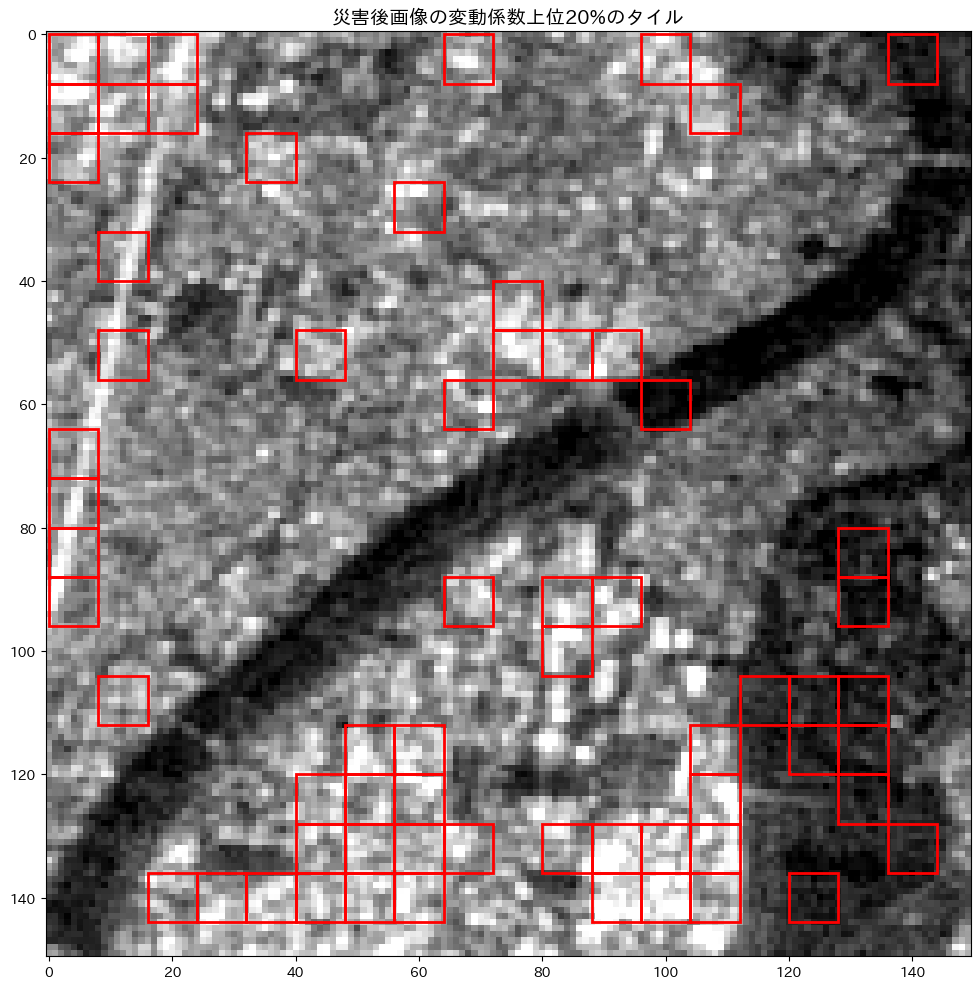

In [66]:
# 災害前画像の変動係数算出
before_coefficients_of_variation = calculate_coefficient_of_variation(before_l_plus, before_l_minus)
before_top_coefficients = extract_top_percentile(
    before_coefficients_of_variation,
    percentile=CV_PERCENTILE_BEFORE
)

# 災害後画像の変動係数算出
after_coefficients_of_variation = calculate_coefficient_of_variation(after_l_plus, after_l_minus)
after_top_coefficients = extract_top_percentile(
    after_coefficients_of_variation,
    percentile=CV_PERCENTILE_AFTER
)

print('=' * 60)
print('変動係数分析結果')
print('=' * 60)
print(f'災害前 - 変動係数の範囲: {np.min(before_coefficients_of_variation):.4f} - {np.max(before_coefficients_of_variation):.4f}')
print(f'災害前 - {CV_PERCENTILE_BEFORE}パーセンタイル閾値: {np.percentile(before_coefficients_of_variation, CV_PERCENTILE_BEFORE):.4f}')
print(f'災害前 - 抽出されたタイル数: {len(before_top_coefficients)}')
print('-' * 60)
print(f'災害後 - 変動係数の範囲: {np.min(after_coefficients_of_variation):.4f} - {np.max(after_coefficients_of_variation):.4f}')
print(f'災害後 - {CV_PERCENTILE_AFTER}パーセンタイル閾値: {np.percentile(after_coefficients_of_variation, CV_PERCENTILE_AFTER):.4f}')
print(f'災害後 - 抽出されたタイル数: {len(after_top_coefficients)}')
print('=' * 60)

# 抽出されたタイルの可視化
visualize_top_tiles(
    before_multilooked,
    before_l_plus_positions,
    before_top_coefficients,
    f'災害前画像の変動係数上位{100-CV_PERCENTILE_BEFORE}%のタイル',
    'figure49.png'
)

visualize_top_tiles(
    after_multilooked,
    after_l_plus_positions,
    after_top_coefficients,
    f'災害後画像の変動係数上位{100-CV_PERCENTILE_AFTER}%のタイル',
    'figure50.png'
)

# 局所閾値の決定と水域抽出

In [67]:
def check_and_return_l_plus_below_average(l_plus, top_coefficients):
    """
    全体のL+タイルの平均値よりも低い平均値を持つL+タイルを抽出する関数
    
    変動係数が高いタイルの中から、さらに平均値が低いタイルを抽出することで、
    水域を含む可能性の高い領域を特定します。
    
    Parameters:
    -----------
    l_plus : list of ndarray
        L+タイルのリスト
    top_coefficients : list of tuple
        上位変動係数のタイル情報
    
    Returns:
    --------
    l_plus_below_average : list of ndarray
        平均値が全体平均より低いL+タイルのリスト
    indices_below_average : list of int
        該当するタイルのインデックスリスト
    """
    all_l_plus_means = [np.nanmean(tile) for tile in l_plus]
    average_of_all_l_plus = np.nanmean(all_l_plus_means)
    
    l_plus_below_average = []
    indices_below_average = []
    for i, _ in top_coefficients:
        top_l_plus_mean = np.nanmean(l_plus[i])
        if top_l_plus_mean < average_of_all_l_plus:
            l_plus_below_average.append(l_plus[i])
            indices_below_average.append(i)
    
    return l_plus_below_average, indices_below_average


def visualize_selected_tiles(image, l_plus_positions, indices_below_average, title, output_filename):
    """
    選択されたL+タイルを可視化する関数
    
    Parameters:
    -----------
    image : ndarray
        ベース画像
    l_plus_positions : list of tuple
        L+タイルの位置情報
    indices_below_average : list of int
        選択されたタイルのインデックスリスト
    title : str
        図のタイトル
    output_filename : str
        出力ファイル名
    """
    fig, ax = plt.subplots(figsize=(10, 10))
    
    p2, p98 = np.nanpercentile(image, [2, 98])
    ax.imshow(image, cmap='gray', vmin=p2, vmax=p98)
    
    for i in indices_below_average:
        y_start, y_end, x_start, x_end = l_plus_positions[i]
        rect = plt.Rectangle(
            (x_start, y_start), x_end - x_start, y_end - y_start,
            edgecolor='red', facecolor='none', linewidth=2
        )
        ax.add_patch(rect)
    
    ax.set_title(title, fontsize=14)
    plt.savefig(os.path.join(PATH_OUTPUT, output_filename), dpi=150, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

水域候補タイルの抽出結果
災害前 - 候補タイル数: 10
災害前 - 全体L+タイル平均値: -5.3295 dB
災害前 - 候補タイル平均値範囲: -12.2657 - -8.4439 dB
------------------------------------------------------------
災害後 - 候補タイル数: 12
災害後 - 全体L+タイル平均値: -4.6204 dB
災害後 - 候補タイル平均値範囲: -15.3397 - -11.6315 dB


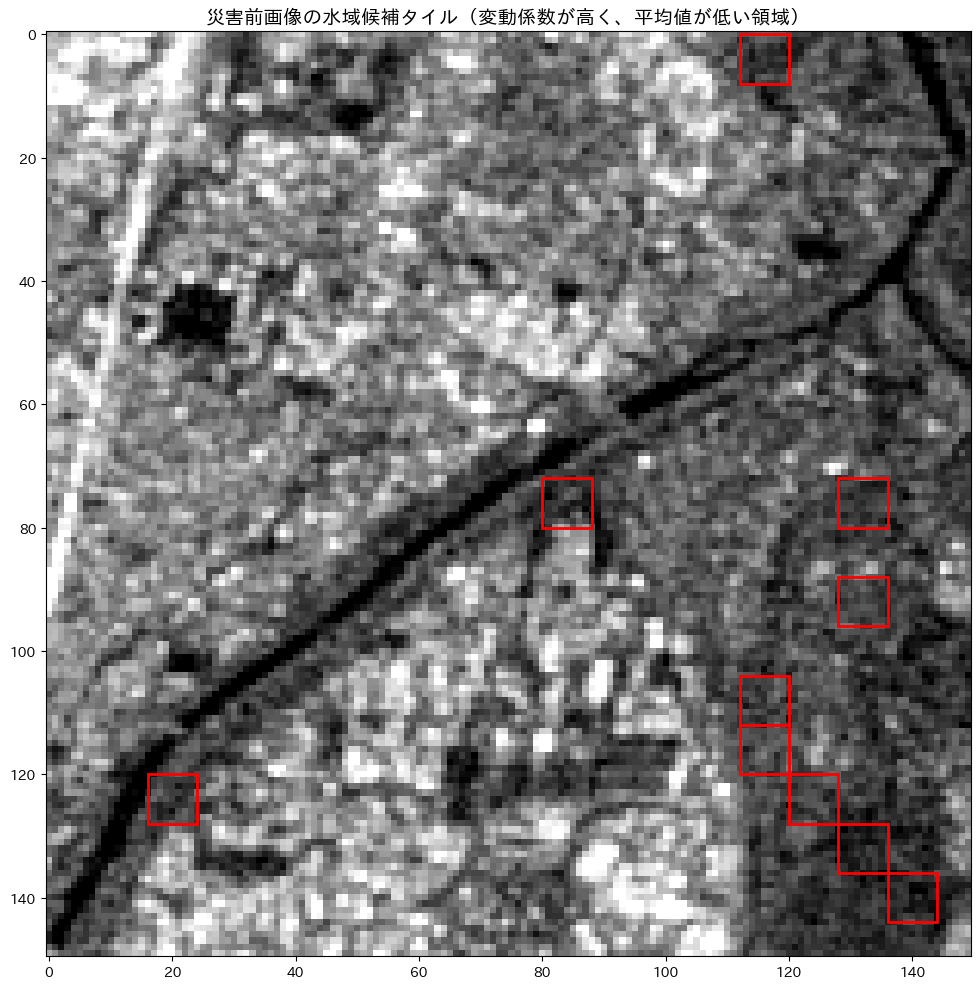

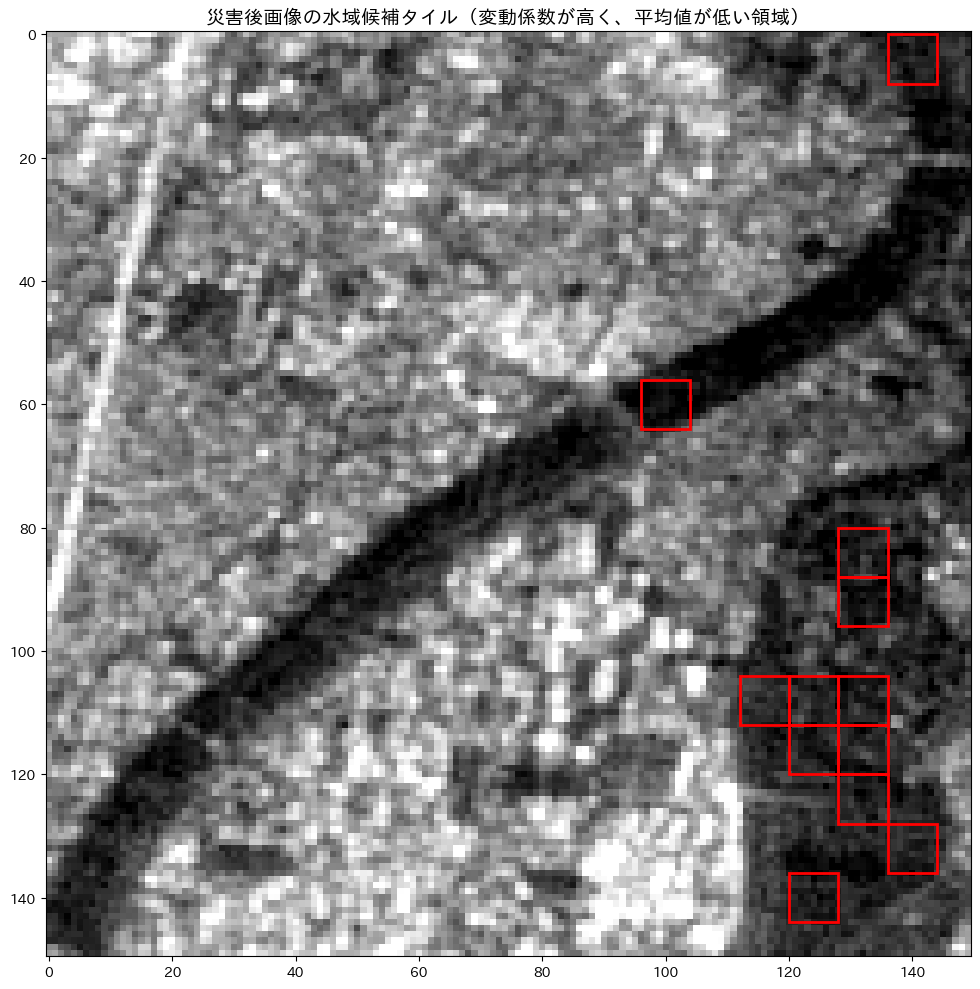

In [68]:
# 災害前画像の水域候補タイル抽出
before_l_plus_below_average, before_indices_below_average = check_and_return_l_plus_below_average(
    before_l_plus,
    before_top_coefficients
)

# 災害後画像の水域候補タイル抽出
after_l_plus_below_average, after_indices_below_average = check_and_return_l_plus_below_average(
    after_l_plus,
    after_top_coefficients
)

# 統計情報の表示
print('=' * 60)
print('水域候補タイルの抽出結果')
print('=' * 60)
all_before_means = [np.nanmean(tile) for tile in before_l_plus]
average_of_all_before = np.nanmean(all_before_means)
print(f'災害前 - 候補タイル数: {len(before_indices_below_average)}')
print(f'災害前 - 全体L+タイル平均値: {average_of_all_before:.4f} dB')
if len(before_l_plus_below_average) > 0:
    before_candidate_means = [np.nanmean(tile) for tile in before_l_plus_below_average]
    print(f'災害前 - 候補タイル平均値範囲: {np.min(before_candidate_means):.4f} - {np.max(before_candidate_means):.4f} dB')

print('-' * 60)
all_after_means = [np.nanmean(tile) for tile in after_l_plus]
average_of_all_after = np.nanmean(all_after_means)
print(f'災害後 - 候補タイル数: {len(after_indices_below_average)}')
print(f'災害後 - 全体L+タイル平均値: {average_of_all_after:.4f} dB')
if len(after_l_plus_below_average) > 0:
    after_candidate_means = [np.nanmean(tile) for tile in after_l_plus_below_average]
    print(f'災害後 - 候補タイル平均値範囲: {np.min(after_candidate_means):.4f} - {np.max(after_candidate_means):.4f} dB')
print('=' * 60)

# 可視化
visualize_selected_tiles(
    before_multilooked,
    before_l_plus_positions,
    before_indices_below_average,
    '災害前画像の水域候補タイル（変動係数が高く、平均値が低い領域）',
    'figure51.png'
)

visualize_selected_tiles(
    after_multilooked,
    after_l_plus_positions,
    after_indices_below_average,
    '災害後画像の水域候補タイル（変動係数が高く、平均値が低い領域）',
    'figure52.png'
)

# 2値化による水域マスクの生成

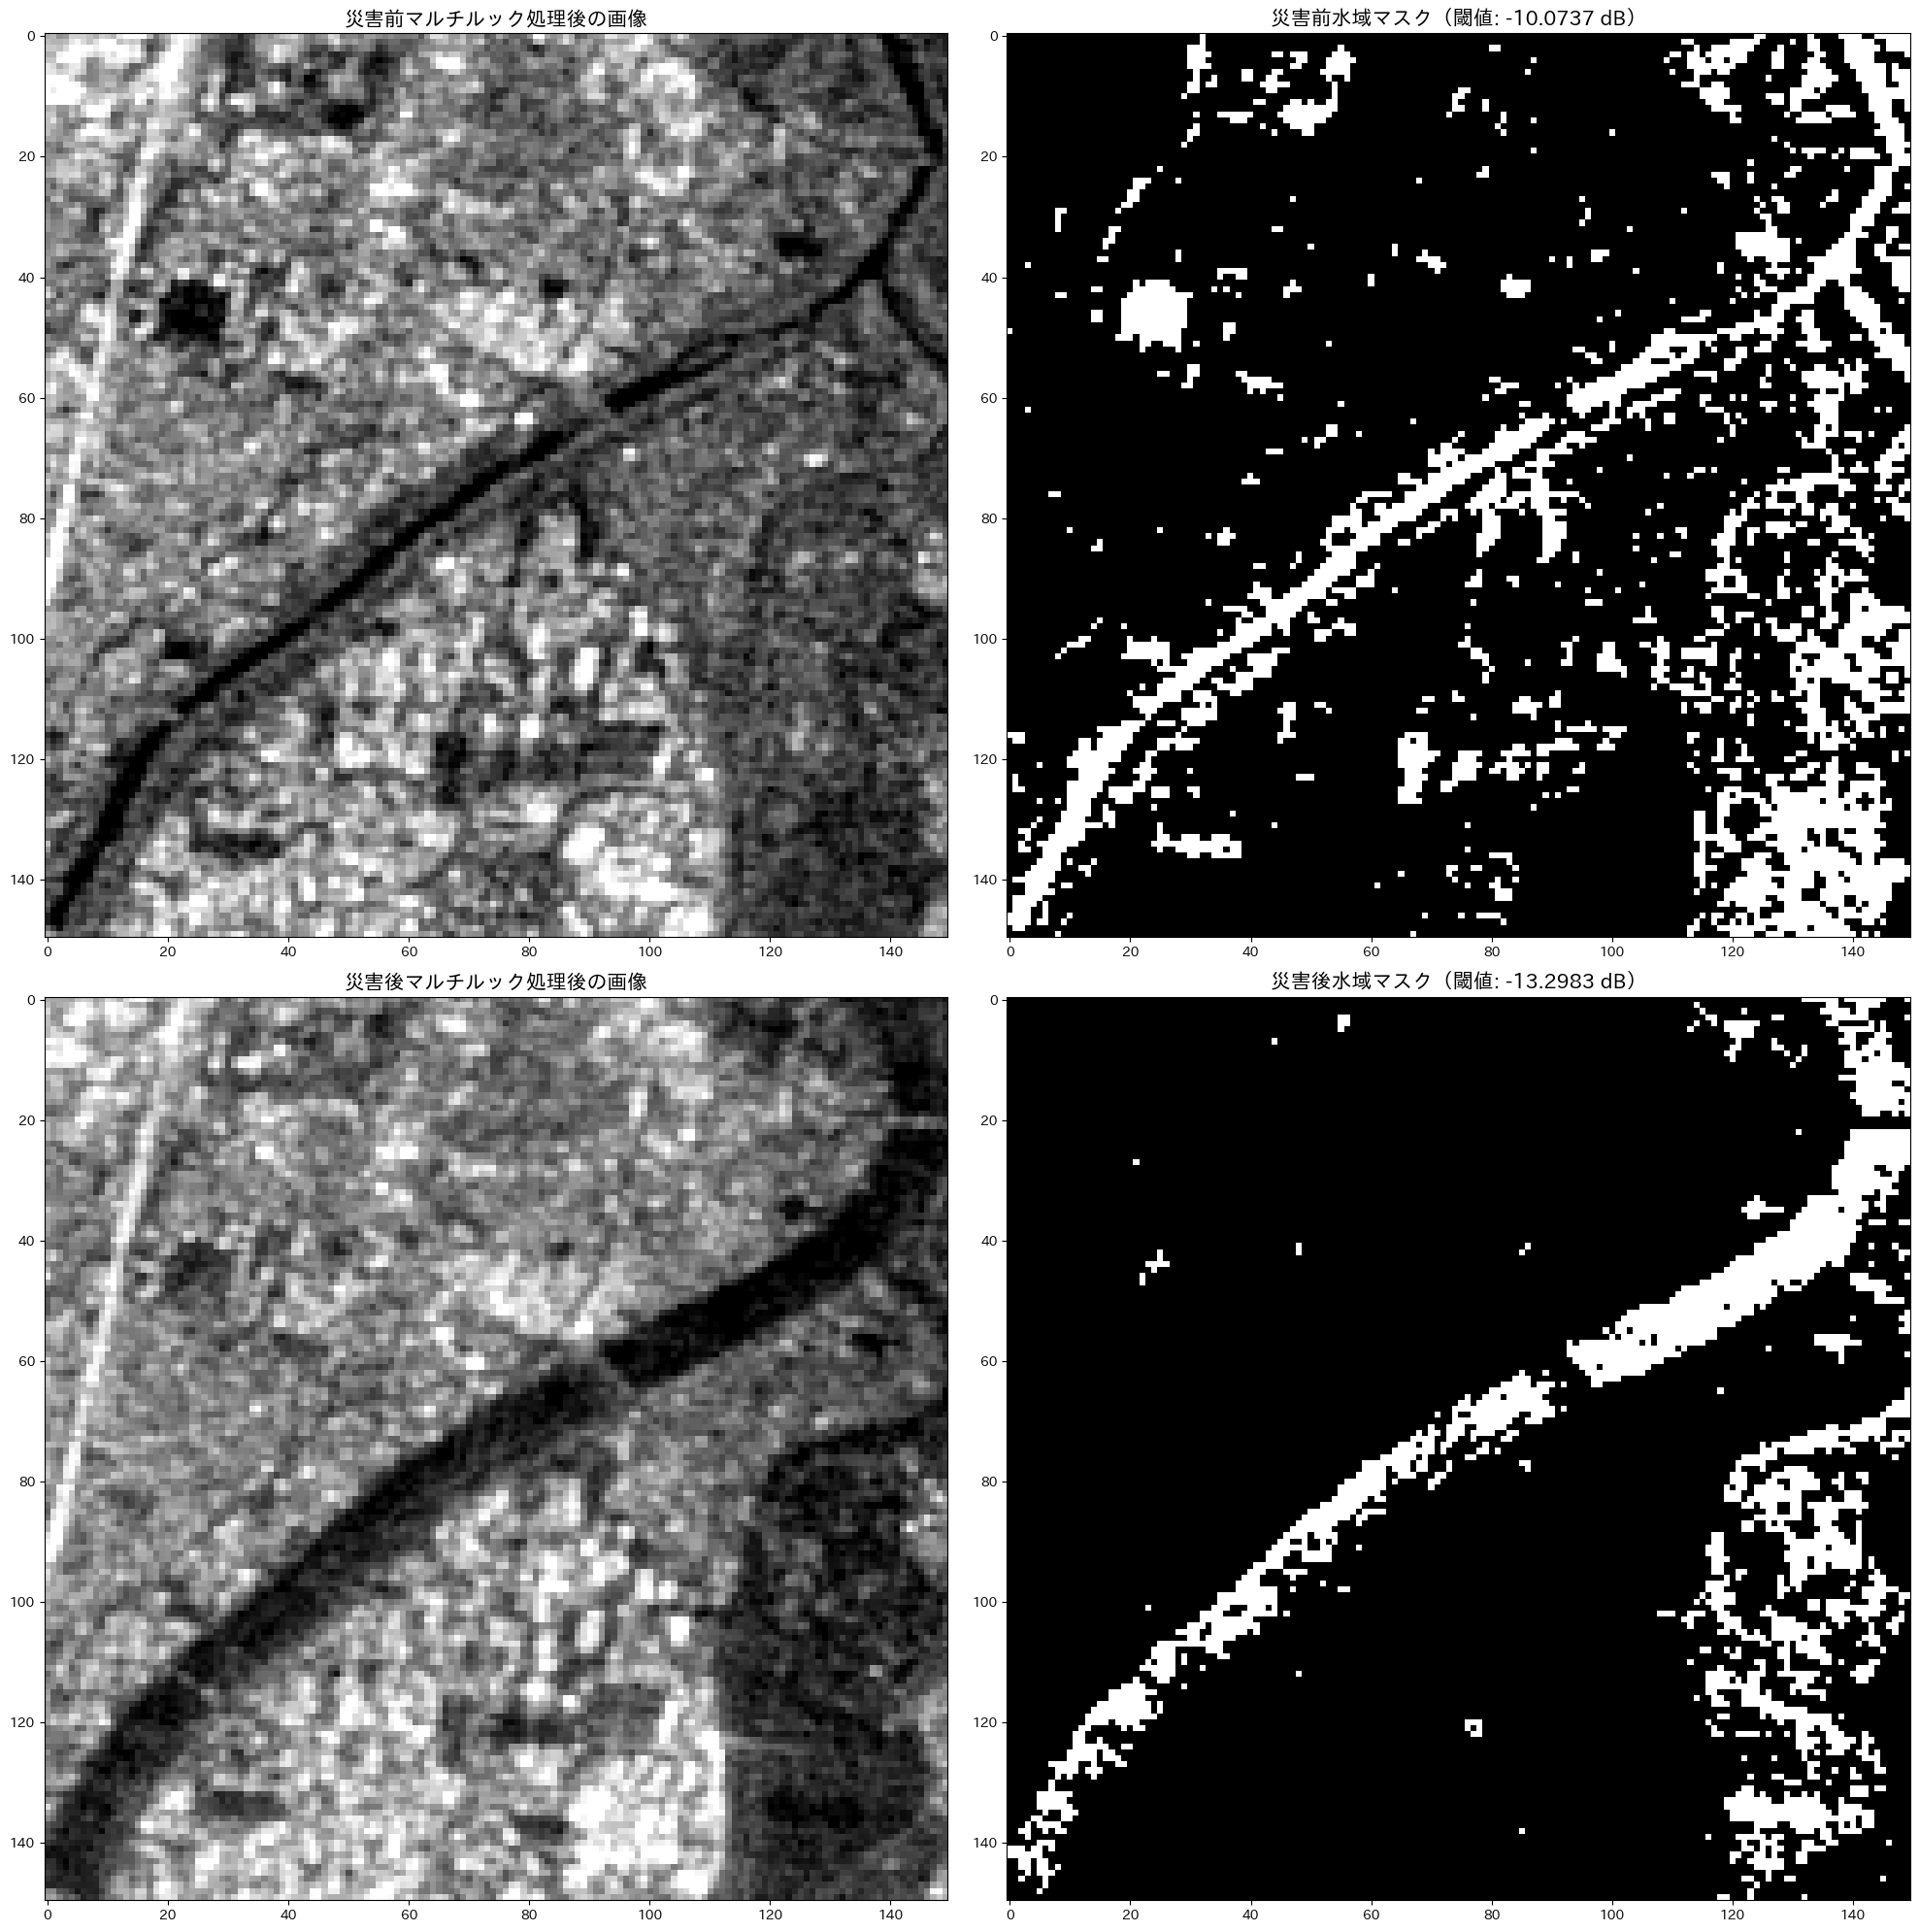

初回局所閾値法による水域抽出完了
災害前 - 決定された閾値: -10.0737 dB
災害前 - 水域ピクセル数: 3925
災害前 - 水域面積率: 17.44%
------------------------------------------------------------
災害後 - 決定された閾値: -13.2983 dB
災害後 - 水域ピクセル数: 2411
災害後 - 水域面積率: 10.72%


In [69]:
# 災害前画像の閾値算出と2値化
before_threshold = np.nanmean(before_l_plus_below_average)
before_binalized = np.where(before_multilooked < before_threshold, 1, 0)

# 災害後画像の閾値算出と2値化
after_threshold = np.nanmean(after_l_plus_below_average)
after_binalized = np.where(after_multilooked < after_threshold, 1, 0)

# 2値化結果を可視化
p2_before, p98_before = np.nanpercentile(before_multilooked, [2, 98])
p2_after, p98_after = np.nanpercentile(after_multilooked, [2, 98])

fig, axes = plt.subplots(2, 2, figsize=(20, 20))

axes[0, 0].imshow(before_multilooked, cmap='gray', vmin=p2_before, vmax=p98_before)
axes[0, 0].set_title('災害前マルチルック処理後の画像', fontsize=15)
axes[0, 0].set_aspect('equal')

axes[0, 1].imshow(before_binalized, cmap='gray')
axes[0, 1].set_title(f'災害前水域マスク（閾値: {before_threshold:.4f} dB）', fontsize=15)
axes[0, 1].set_aspect('equal')

axes[1, 0].imshow(after_multilooked, cmap='gray', vmin=p2_after, vmax=p98_after)
axes[1, 0].set_title('災害後マルチルック処理後の画像', fontsize=15)
axes[1, 0].set_aspect('equal')

axes[1, 1].imshow(after_binalized, cmap='gray')
axes[1, 1].set_title(f'災害後水域マスク（閾値: {after_threshold:.4f} dB）', fontsize=15)
axes[1, 1].set_aspect('equal')

plt.savefig(os.path.join(PATH_OUTPUT, 'figure53.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

print('=' * 60)
print('初回局所閾値法による水域抽出完了')
print('=' * 60)
print(f'災害前 - 決定された閾値: {before_threshold:.4f} dB')
print(f'災害前 - 水域ピクセル数: {np.sum(before_binalized)}')
print(f'災害前 - 水域面積率: {np.sum(before_binalized) / before_binalized.size * 100:.2f}%')
print('-' * 60)
print(f'災害後 - 決定された閾値: {after_threshold:.4f} dB')
print(f'災害後 - 水域ピクセル数: {np.sum(after_binalized)}')
print(f'災害後 - 水域面積率: {np.sum(after_binalized) / after_binalized.size * 100:.2f}%')
print('=' * 60)

# 災害前水域マスクの精緻化（2回目の局所閾値処理）

In [70]:
# 災害前のマスク画像に局所的閾値法を再適用
before_binalized_multilooked = np.where(before_binalized, before_multilooked, np.nan)

# 再度タイル分割（より小さいタイルサイズで）
before_re_l_plus, before_re_l_plus_positions, before_re_l_minus, before_re_l_minus_positions = create_tiles(
    before_binalized_multilooked,
    tile_size=RETILE_SIZE
)

# 変動係数の再計算
before_re_coefficients_of_variation = calculate_coefficient_of_variation(before_re_l_plus, before_re_l_minus)
before_re_top_coefficients = extract_top_percentile(
    before_re_coefficients_of_variation,
    percentile=RECV_PERCENTILE
)

# 水域候補タイルの再抽出
before_re_l_plus_below_average, before_re_indices_below_average = check_and_return_l_plus_below_average(
    before_re_l_plus,
    before_re_top_coefficients
)

# 再閾値化
before_rethreshold = np.nanmean(before_re_l_plus_below_average)
before_rebinalized = np.where(before_binalized_multilooked < before_rethreshold, 1, 0)

print('=' * 60)
print('災害前水域マスクの精緻化完了')
print('=' * 60)
print(f'再タイル化サイズ: {RETILE_SIZE}×{RETILE_SIZE}')
print(f'再処理タイル数: {len(before_re_l_plus)}')
print(f'再決定された閾値: {before_rethreshold:.4f} dB')
print(f'精緻化後の水域ピクセル数: {np.sum(before_rebinalized)}')
print(f'精緻化後の水域面積率: {np.sum(before_rebinalized) / before_rebinalized.size * 100:.2f}%')
print('=' * 60)

災害前水域マスクの精緻化完了
再タイル化サイズ: 4×4
再処理タイル数: 8
再決定された閾値: -15.6096 dB
精緻化後の水域ピクセル数: 338
精緻化後の水域面積率: 1.50%


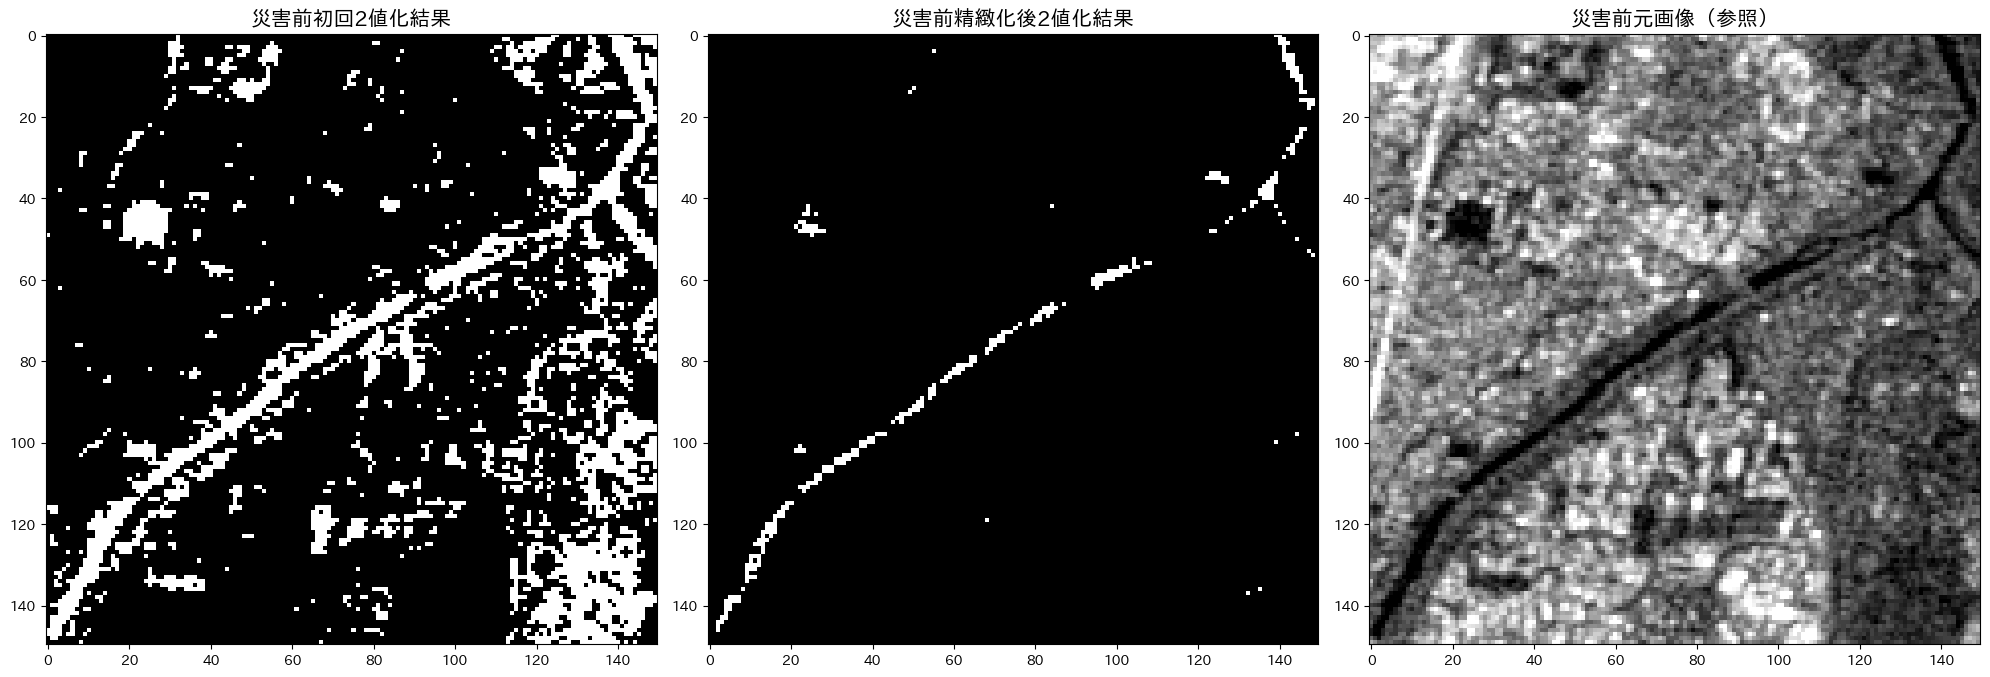

In [71]:
# 精緻化前後の比較可視化
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

axes[0].imshow(before_binalized, cmap='gray')
axes[0].set_title('災害前初回2値化結果', fontsize=15)
axes[0].set_aspect('equal')

axes[1].imshow(before_rebinalized, cmap='gray')
axes[1].set_title('災害前精緻化後2値化結果', fontsize=15)
axes[1].set_aspect('equal')

axes[2].imshow(before_multilooked, cmap='gray', vmin=p2_before, vmax=p98_before)
axes[2].set_title('災害前元画像（参照）', fontsize=15)
axes[2].set_aspect('equal')

plt.savefig(os.path.join(PATH_OUTPUT, 'figure54.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

# 洪水域の抽出（災害前後の差分）

In [72]:
# 災害前後の差分計算
# 差分 = 災害後の水域 - 災害前の水域
# 結果が1の領域が新たに浸水した領域（洪水域）
diff = after_binalized - before_rebinalized
flood_delineation = np.where(diff == 1, 1, 0)

# 統計情報の計算
flood_pixel_count = np.sum(flood_delineation)
total_pixels = flood_delineation.size
flood_area_ratio = flood_pixel_count / total_pixels * 100

print('=' * 60)
print('洪水域抽出結果')
print('=' * 60)
print(f'洪水域ピクセル数: {flood_pixel_count}')
print(f'全体ピクセル数: {total_pixels}')
print(f'洪水域面積率: {flood_area_ratio:.2f}%')
print(f'災害前水域ピクセル数: {np.sum(before_rebinalized)}')
print(f'災害後水域ピクセル数: {np.sum(after_binalized)}')
print(f'増加ピクセル数: {np.sum(after_binalized) - np.sum(before_rebinalized)}')
print('=' * 60)

洪水域抽出結果
洪水域ピクセル数: 2180
全体ピクセル数: 22500
洪水域面積率: 9.69%
災害前水域ピクセル数: 338
災害後水域ピクセル数: 2411
増加ピクセル数: 2073


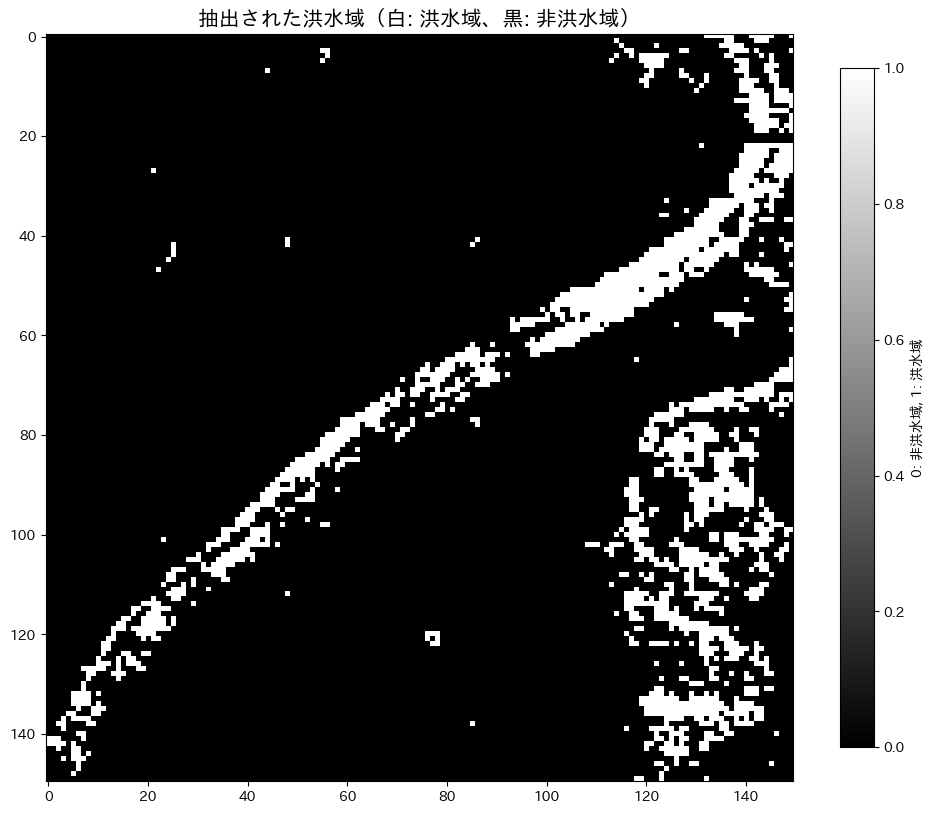

In [73]:
# 洪水域の可視化
fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(flood_delineation, cmap='gray')
ax.set_title('抽出された洪水域（白: 洪水域、黒: 非洪水域）', fontsize=15)
ax.set_aspect('equal')
fig.colorbar(im, ax=ax, label='0: 非洪水域, 1: 洪水域', shrink=0.7)
plt.savefig(os.path.join(PATH_OUTPUT, 'figure55.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

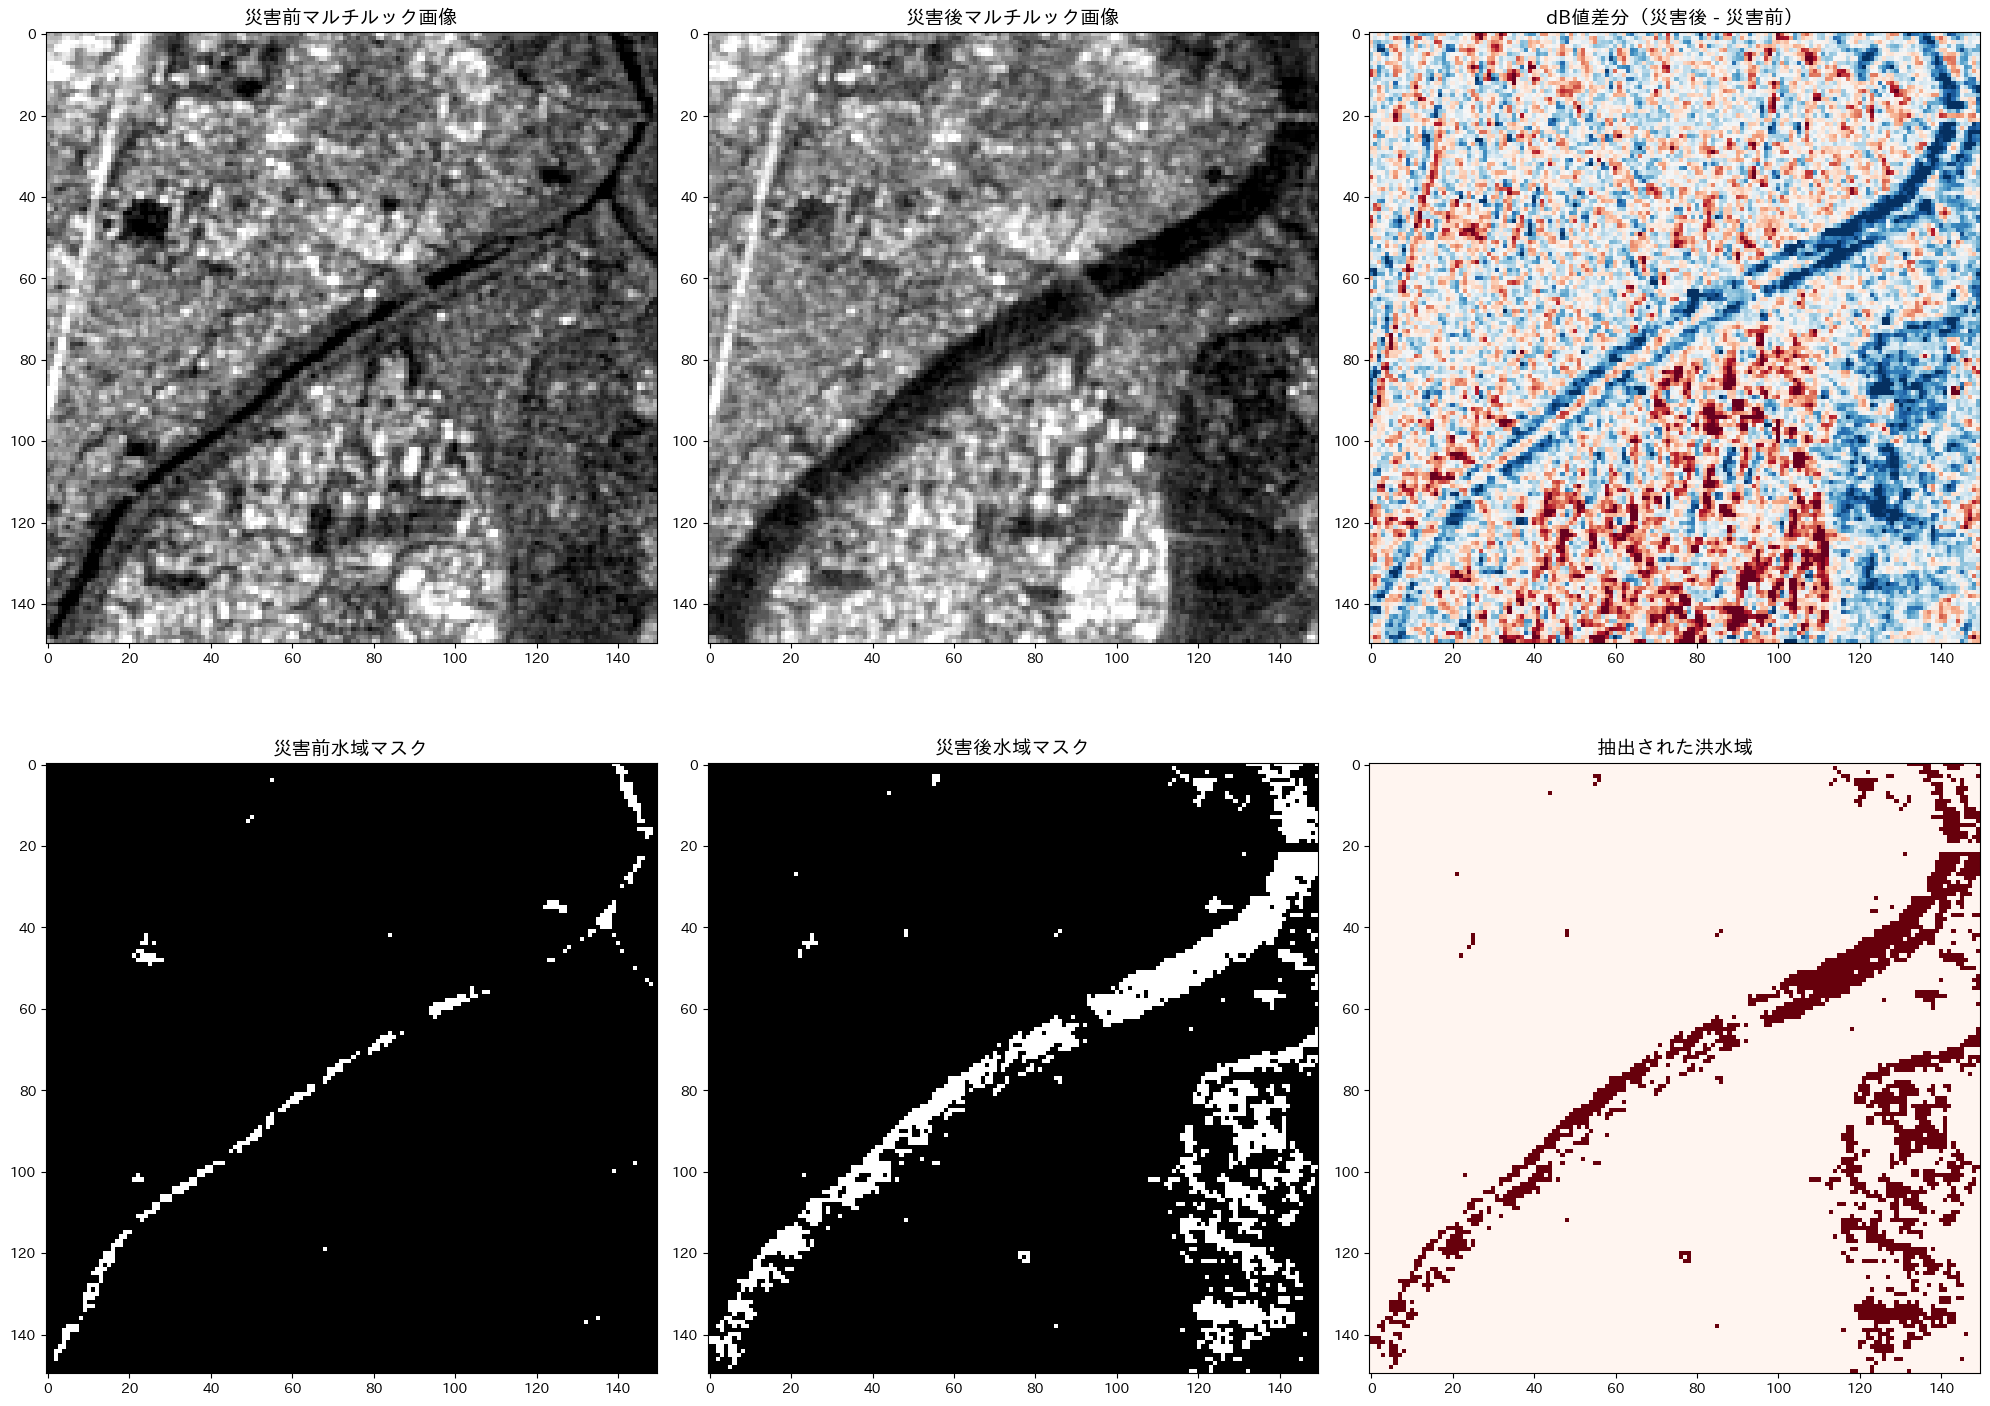

In [74]:
# 災害前後と洪水域の総合比較
fig, axes = plt.subplots(2, 3, figsize=(20, 15))

im00 = axes[0, 0].imshow(before_multilooked, cmap='gray', vmin=p2_before, vmax=p98_before)
axes[0, 0].set_title('災害前マルチルック画像', fontsize=14)
axes[0, 0].set_aspect('equal')

im01 = axes[0, 1].imshow(after_multilooked, cmap='gray', vmin=p2_after, vmax=p98_after)
axes[0, 1].set_title('災害後マルチルック画像', fontsize=14)
axes[0, 1].set_aspect('equal')

# 差分画像（dB値の差）
diff_db = after_multilooked - before_multilooked
p2_diff, p98_diff = np.nanpercentile(diff_db, [2, 98])
im02 = axes[0, 2].imshow(diff_db, cmap='RdBu_r', vmin=p2_diff, vmax=p98_diff)
axes[0, 2].set_title('dB値差分（災害後 - 災害前）', fontsize=14)
axes[0, 2].set_aspect('equal')

im10 = axes[1, 0].imshow(before_rebinalized, cmap='gray')
axes[1, 0].set_title('災害前水域マスク', fontsize=14)
axes[1, 0].set_aspect('equal')

im11 = axes[1, 1].imshow(after_binalized, cmap='gray')
axes[1, 1].set_title('災害後水域マスク', fontsize=14)
axes[1, 1].set_aspect('equal')

im12 = axes[1, 2].imshow(flood_delineation, cmap='Reds')
axes[1, 2].set_title('抽出された洪水域', fontsize=14)
axes[1, 2].set_aspect('equal')

plt.savefig(os.path.join(PATH_OUTPUT, 'figure56.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

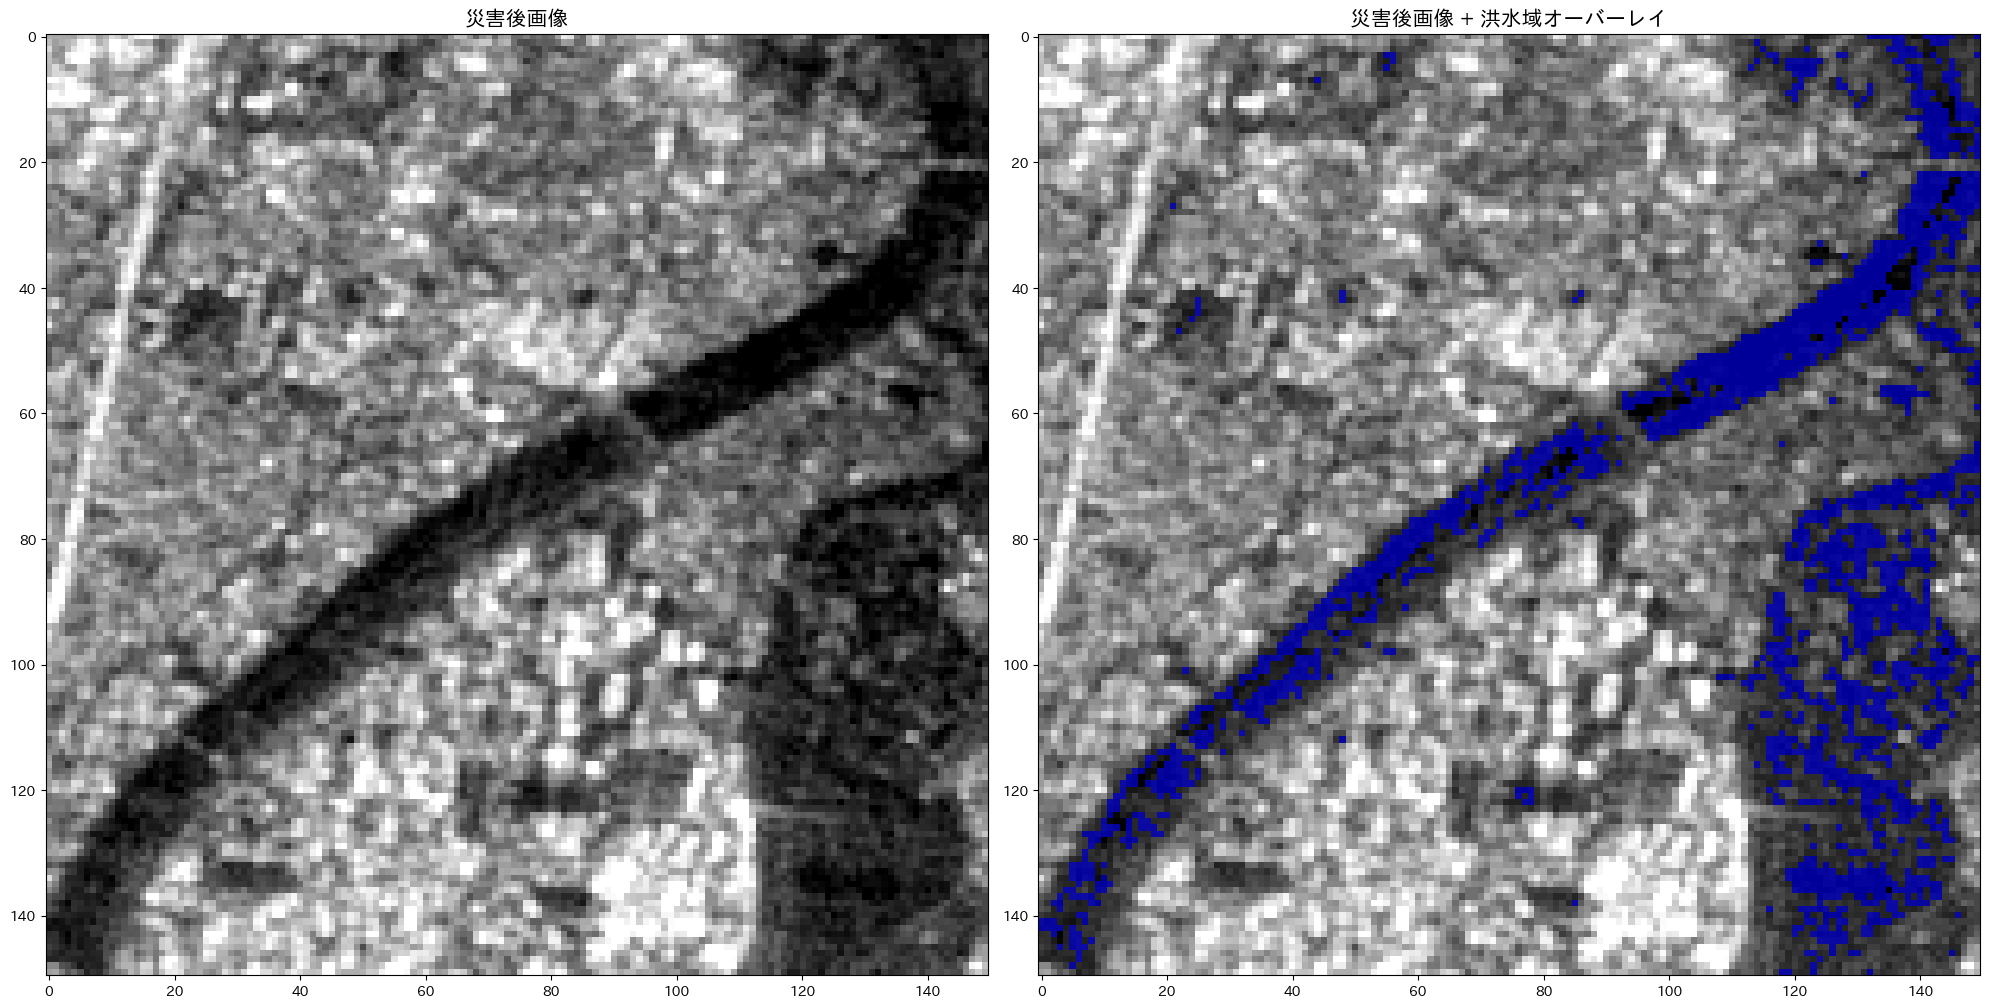

In [75]:
# 災害後画像に洪水域をオーバーレイ
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

axes[0].imshow(after_multilooked, cmap='gray', vmin=p2_after, vmax=p98_after)
axes[0].set_title('災害後画像', fontsize=15)
axes[0].set_aspect('equal')

axes[1].imshow(after_multilooked, cmap='gray', vmin=p2_after, vmax=p98_after)
# 洪水域を赤色でオーバーレイ
flood_overlay = np.ma.masked_where(flood_delineation == 0, flood_delineation)
blue_cmap = ListedColormap(['blue'])
axes[1].imshow(flood_overlay, cmap=blue_cmap, alpha=0.6)
axes[1].set_title('災害後画像 + 洪水域オーバーレイ', fontsize=15)
axes[1].set_aspect('equal')

plt.savefig(os.path.join(PATH_OUTPUT, 'figure57.png'), dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()